<a href="https://colab.research.google.com/github/mertuu/stock-price-prediction/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

# Basit bir tensör (matris) oluşturalım
x = torch.rand(3, 3)
print("PyTorch Başarıyla Çalışıyor! Sürüm:", torch.__version__)
print("\nRastgele oluşturulan 3x3 Tensör:\n", x)

PyTorch Başarıyla Çalışıyor! Sürüm: 2.11.0+cpu

Rastgele oluşturulan 3x3 Tensör:
 tensor([[0.0984, 0.6197, 0.2453],
        [0.8145, 0.7208, 0.5116],
        [0.8571, 0.8473, 0.8317]])


In [ ]:
import pandas as pd
import yfinance as yf

print("Veri indiriliyor, lütfen bekleyin...")
# Amazon (AMZN) hissesinin son 10 yıllık verisini çekiyoruz
df = yf.download('AMZN', start='2014-01-01', end='2024-01-01')

# Bizim işimize yarayacak olan tek şey 'Close' (Kapanış) fiyatı
data = df[['Close']].copy()

print("\n--- İlk 5 Günlük Veri ---")
display(data.head())
print(f"\nToplam {len(data)} günlük veri çekildi.")

Veri indiriliyor, lütfen bekleyin...


/tmp/ipykernel_9097/2078803075.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AMZN', start='2014-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


--- İlk 5 Günlük Veri ---


Price,Close
Ticker,AMZN
Date,
2014-01-02,19.898500
2014-01-03,19.822001
2014-01-06,19.681499
2014-01-07,19.901501
2014-01-08,20.096001



Toplam 2516 günlük veri çekildi.


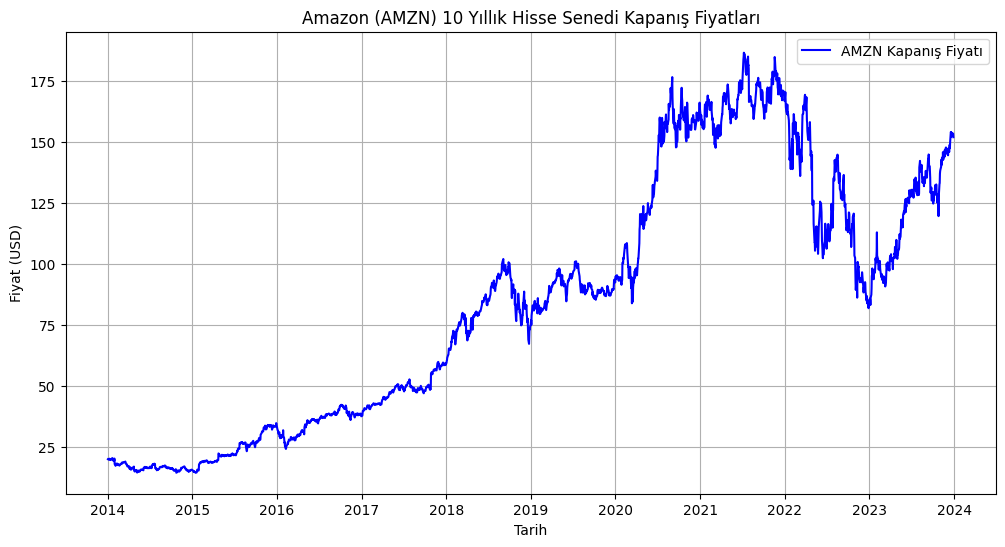

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], color='blue', label='AMZN Kapanış Fiyatı')
plt.title('Amazon (AMZN) 10 Yıllık Hisse Senedi Kapanış Fiyatları')
plt.xlabel('Tarih')
plt.ylabel('Fiyat (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# PyTorch modelleri genellikle -1 ile 1 arasındaki verilerle daha iyi çalışır
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fiyatları -1 ile 1 arasına sıkıştırıyoruz
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))

print("Orijinal ilk 3 fiyat:\n", data['Close'].values[:3])
print("\nÖlçeklendirilmiş (Sıkıştırılmış) ilk 3 fiyat:\n", scaled_data[:3])

Orijinal ilk 3 fiyat:
 [[19.89850044]
 [19.8220005 ]
 [19.68149948]]

Ölçeklendirilmiş (Sıkıştırılmış) ilk 3 fiyat:
 [[-0.93553706]
 [-0.93642544]
 [-0.93805706]]


In [ ]:
import torch

# Kayan pencere fonksiyonumuz
def create_sliding_window(dataset, lookback=20):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        # 20 günlük geçmiş (Girdi)
        X.append(dataset[i:(i + lookback), 0])
        # 21. gün (Tahmin etmeye çalıştığımız hedef)
        y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(y)

lookback_days = 20
X, y = create_sliding_window(scaled_data, lookback_days)

print(f"Toplam oluşturulan dizi (örnek) sayısı: {len(X)}")
print(f"İlk girdi (X) dizisinin boyutu: {X[0].shape} (20 günlük veri)")
print(f"İlk hedef (y) değeri: {y[0]:.4f}")

Toplam oluşturulan dizi (örnek) sayısı: 2496
İlk girdi (X) dizisinin boyutu: (20,) (20 günlük veri)
İlk hedef (y) değeri: -0.9583


In [ ]:
# Verinin %80'ini eğitim, %20'sini test için ayırıyoruz
train_size = int(len(X) * 0.8)

# Zaman serisi olduğu için veriyi rastgele bölemeyiz, kronolojik bölmeliyiz!
X_train_raw, y_train_raw = X[:train_size], y[:train_size]
X_test_raw, y_test_raw = X[train_size:], y[train_size:]

# Numpy dizilerini PyTorch Tensörlerine çeviriyoruz ve
# RNN/LSTM mimarisinin istediği [Örnek Sayısı, Zaman Adımı, Özellik Sayısı] şekline (reshape) sokuyoruz.
X_train = torch.tensor(X_train_raw, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).unsqueeze(-1)

X_test = torch.tensor(X_test_raw, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test_raw, dtype=torch.float32).unsqueeze(-1)

print("--- PyTorch Tensörleri Hazır ---")
print(f"Eğitim verisi (X_train) boyutu: {X_train.shape}")
print(f"Test verisi (X_test) boyutu: {X_test.shape}")

--- PyTorch Tensörleri Hazır ---
Eğitim verisi (X_train) boyutu: torch.Size([1996, 20, 1])
Test verisi (X_test) boyutu: torch.Size([500, 20, 1])


In [ ]:
import torch.nn as nn

class StockLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=2, output_dim=1):
        super(StockLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM Katmanı: Geçmiş veriyi okuyan ve hafızada tutan kısım
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # Doğrusal (Linear) Katman: Hafızadaki bilgileri tek bir fiyat tahminine çeviren kısım
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # İleri Besleme (Forward Pass): Verinin modelden geçiş rotası
        out, (hn, cn) = self.lstm(x)

        # LSTM bize her gün için bir çıktı üretir (20 gün).
        # Biz sadece EN SON günün (20. günün) ürettiği nihai bilgiyi istiyoruz.
        out = out[:, -1, :]

        # Son günün bilgisini tahmin katmanına veriyoruz
        out = self.fc(out)
        return out

print("LSTM Modeli başarıyla tanımlandı!")

LSTM Modeli başarıyla tanımlandı!


In [ ]:
class StockGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=2, output_dim=1):
        super(StockGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Tek fark buradaki nn.GRU kısmı
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # GRU'da 'cn' (cell state) yoktur, sadece 'hn' (hidden state) döner
        out, hn = self.gru(x)

        # Yine sadece son zaman adımının (20. günün) çıktısını alıyoruz
        out = out[:, -1, :]
        out = self.fc(out)
        return out

print("GRU Modeli başarıyla tanımlandı!")

GRU Modeli başarıyla tanımlandı!


In [ ]:
# Modelleri oluşturuyoruz
lstm_model = StockLSTM(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1)
gru_model = StockGRU(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1)

print(lstm_model)
print("\n--- Modeller Eğitime Hazır ---")

StockLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

--- Modeller Eğitime Hazır ---


In [ ]:
import torch.optim as optim
import torch.nn as nn
import time

# 1. Hata Hesaplayıcı (MSELoss) ve Optimize Edici (Adam)
criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.01)

# Model veriyi kaç kez baştan sona görecek?
num_epochs = 100

print("LSTM Modeli Eğitimi Başlıyor...\n")
start_time = time.time()

# 2. Eğitim Döngüsü
for epoch in range(num_epochs):
    lstm_model.train() # Modeli 'eğitim' moduna alıyoruz

    # Tahmin yap
    y_pred = lstm_model(X_train)

    # Hatayı hesapla
    loss = criterion(y_pred, y_train)

    # Hatayı geriye yayarak modeli düzelt
    optimizer_lstm.zero_grad()
    loss.backward()
    optimizer_lstm.step()

    # Her 10 turda bir hatanın düşüşünü ekrana yazdır
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Hata (Loss): {loss.item():.4f}')

print(f"\nLSTM Eğitimi Tamamlandı! Süre: {time.time() - start_time:.2f} saniye")

LSTM Modeli Eğitimi Başlıyor...

Epoch [10/100], Hata (Loss): 0.0536
Epoch [20/100], Hata (Loss): 0.0129
Epoch [30/100], Hata (Loss): 0.0048
Epoch [40/100], Hata (Loss): 0.0026
Epoch [50/100], Hata (Loss): 0.0012
Epoch [60/100], Hata (Loss): 0.0009
Epoch [70/100], Hata (Loss): 0.0007
Epoch [80/100], Hata (Loss): 0.0006
Epoch [90/100], Hata (Loss): 0.0006
Epoch [100/100], Hata (Loss): 0.0006

LSTM Eğitimi Tamamlandı! Süre: 78.38 saniye


In [ ]:
# GRU için kendi optimize edicisini (Adam) tanımlıyoruz
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.01)

print("GRU Modeli Eğitimi Başlıyor...\n")
start_time_gru = time.time()

for epoch in range(num_epochs): # num_epochs yukarıda 100 olarak belirlenmişti
    gru_model.train()

    # Tahmin yap
    y_pred_gru = gru_model(X_train)

    # Hatayı hesapla
    loss_gru = criterion(y_pred_gru, y_train)

    # Modeli güncelle
    optimizer_gru.zero_grad()
    loss_gru.backward()
    optimizer_gru.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Hata (Loss): {loss_gru.item():.4f}')

time_gru = time.time() - start_time_gru
print(f"\nGRU Eğitim Tamamlandı! Süre: {time_gru:.2f} saniye")

GRU Modeli Eğitimi Başlıyor...

Epoch [10/100], Hata (Loss): 0.1000
Epoch [20/100], Hata (Loss): 0.0016
Epoch [30/100], Hata (Loss): 0.0023
Epoch [40/100], Hata (Loss): 0.0027
Epoch [50/100], Hata (Loss): 0.0015
Epoch [60/100], Hata (Loss): 0.0007
Epoch [70/100], Hata (Loss): 0.0006
Epoch [80/100], Hata (Loss): 0.0006
Epoch [90/100], Hata (Loss): 0.0005
Epoch [100/100], Hata (Loss): 0.0005

GRU Eğitim Tamamlandı! Süre: 45.09 saniye


In [ ]:
from sklearn.metrics import mean_squared_error

# Modelleri test moduna alıyoruz (Artık öğrenme yok, sadece sınav var)
lstm_model.eval()
gru_model.eval()

# torch.no_grad() ile gereksiz hesaplamaları kapatıyoruz (hız için)
with torch.no_grad():
    # Modeller test verisine bakıp tahmin yapıyor (Çıktılar -1 ile 1 arasında)
    lstm_preds = lstm_model(X_test).numpy()
    gru_preds = gru_model(X_test).numpy()
    y_test_actual = y_test.numpy()

# Tahminleri -1,1 aralığından orijinal Dolar ($) fiyatlarına geri döndürüyoruz
lstm_preds_real = scaler.inverse_transform(lstm_preds)
gru_preds_real = scaler.inverse_transform(gru_preds)
y_test_real = scaler.inverse_transform(y_test_actual)

# RMSE (Kök Ortalama Kare Hata) Hesaplıyoruz
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, lstm_preds_real))
rmse_gru = np.sqrt(mean_squared_error(y_test_real, gru_preds_real))

print("--- Test Sınavı Sonuçları ---")
print(f"LSTM'in ortalama hata payı: ${rmse_lstm:.2f}")
print(f"GRU'nun ortalama hata payı: ${rmse_gru:.2f}")

# İlk 3 günün tahminlerine yakından bakalım
print("\n--- İlk 3 Test Günü Detayı ---")
for i in range(3):
    print(f"Gün {i+1}: Gerçek: ${y_test_real[i][0]:.2f} | LSTM: ${lstm_preds_real[i][0]:.2f} | GRU: ${gru_preds_real[i][0]:.2f}")

--- Test Sınavı Sonuçları ---
LSTM'in ortalama hata payı: $4.23
GRU'nun ortalama hata payı: $3.79

--- İlk 3 Test Günü Detayı ---
Gün 1: Gerçek: $167.52 | LSTM: $168.96 | GRU: $168.72
Gün 2: Gerçek: $164.36 | LSTM: $168.64 | GRU: $167.41
Gün 3: Gerçek: $163.25 | LSTM: $167.47 | GRU: $165.16


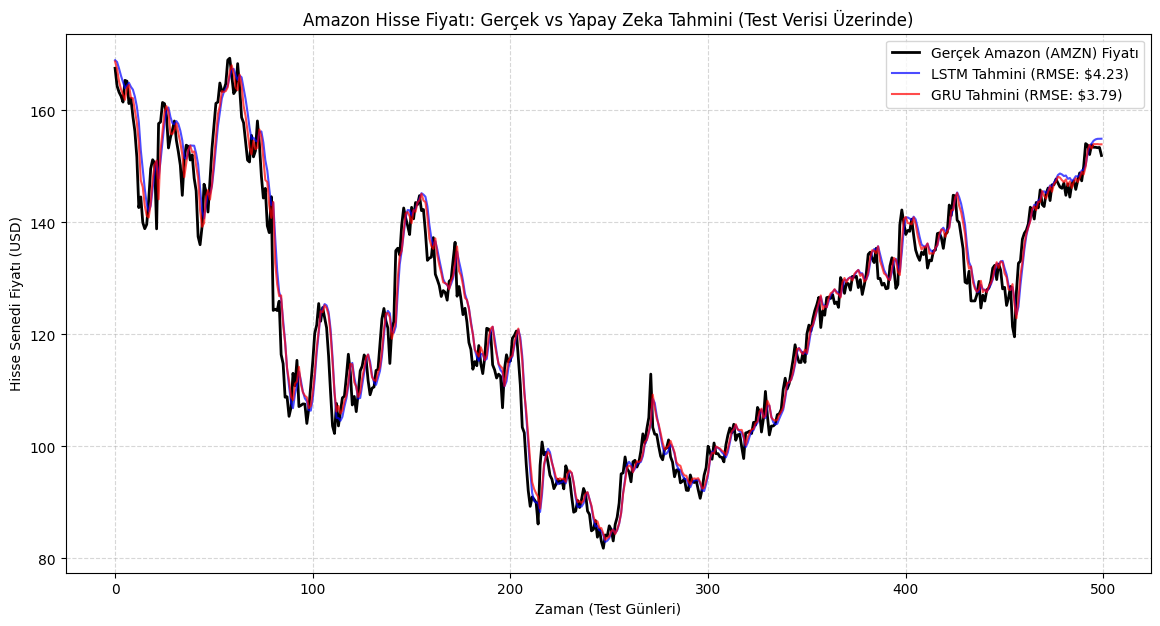

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Gerçek Fiyat Çizgisi (Siyah)
plt.plot(y_test_real, label='Gerçek Amazon (AMZN) Fiyatı', color='black', linewidth=2)

# LSTM Tahmin Çizgisi (Mavi)
plt.plot(lstm_preds_real, label=f'LSTM Tahmini (RMSE: ${rmse_lstm:.2f})', color='blue', alpha=0.7)

# GRU Tahmin Çizgisi (Kırmızı)
plt.plot(gru_preds_real, label=f'GRU Tahmini (RMSE: ${rmse_gru:.2f})', color='red', alpha=0.7)

plt.title('Amazon Hisse Fiyatı: Gerçek vs Yapay Zeka Tahmini (Test Verisi Üzerinde)')
plt.xlabel('Zaman (Test Günleri)')
plt.ylabel('Hisse Senedi Fiyatı (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()